# Rural Microfinance: Model Training & Feature Selection

We take the cleaned rural dataset and:
1. Train a base XGBoost model on all features
2. Extract the Top 15 most predictive features
3. Retrain a production model on ONLY those features
4. Evaluate on the held-out test set
5. Save model + feature metadata to `backend/ml_models/rural_microfinance/`

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import json
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score
import warnings
warnings.filterwarnings('ignore')

plt.style.use('fivethirtyeight')

DATA_PATH = '../../data/processed/rural_microfinance/cleaned_rural.csv'
df = pd.read_csv(DATA_PATH)
print(f"Dataset Shape: {df.shape}")
print(f"TARGET distribution: {df['TARGET'].value_counts().to_dict()}")
print(f"Default Rate: {df['TARGET'].mean()*100:.2f}%")

Dataset Shape: (40000, 71)
TARGET distribution: {0: 34000, 1: 6000}
Default Rate: 15.00%


### Step 1: Train/Test Split

In [2]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]} rows   |   Test: {X_test.shape[0]} rows")
print(f"Train default rate: {y_train.mean():.2%}   |   Test default rate: {y_test.mean():.2%}")
print(f"Total features for base model: {X_train.shape[1]}")

Train: 32000 rows   |   Test: 8000 rows
Train default rate: 15.00%   |   Test default rate: 15.00%
Total features for base model: 70


### Step 2: Train Base XGBoost on ALL Features

In [3]:
scale_pos_weight = (len(y_train) - y_train.sum()) / y_train.sum()
print(f"scale_pos_weight (class imbalance correction): {scale_pos_weight:.2f}")

base_model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

print("\nTraining base model (all features)...")
base_model.fit(X_train, y_train)

val_preds = base_model.predict_proba(X_test)[:, 1]
print(f"Base Model ROC-AUC: {roc_auc_score(y_test, val_preds):.4f}")

scale_pos_weight (class imbalance correction): 5.67

Training base model (all features)...
Base Model ROC-AUC: 0.9943


### Step 3: Feature Selection - Extract Top 15

The model has now analyzed every single column. We extract only the
Top 15 most important features for the production web app.

--- Top 15 Features for Production ---
 1. DTI_ratio
 2. young_dependents
 3. social_class_OBC
 4. loan_purpose_Eateries
 5. secondary_business_Other
 6. water_availabity
 7. social_class_Minority
 8. social_class_SC
 9. total_dependents
10. loan_installments
11. old_dependents
12. primary_business_Other
13. loan_purpose_Business Services - II
14. primary_business_Food_Trade
15. type_of_house_Other


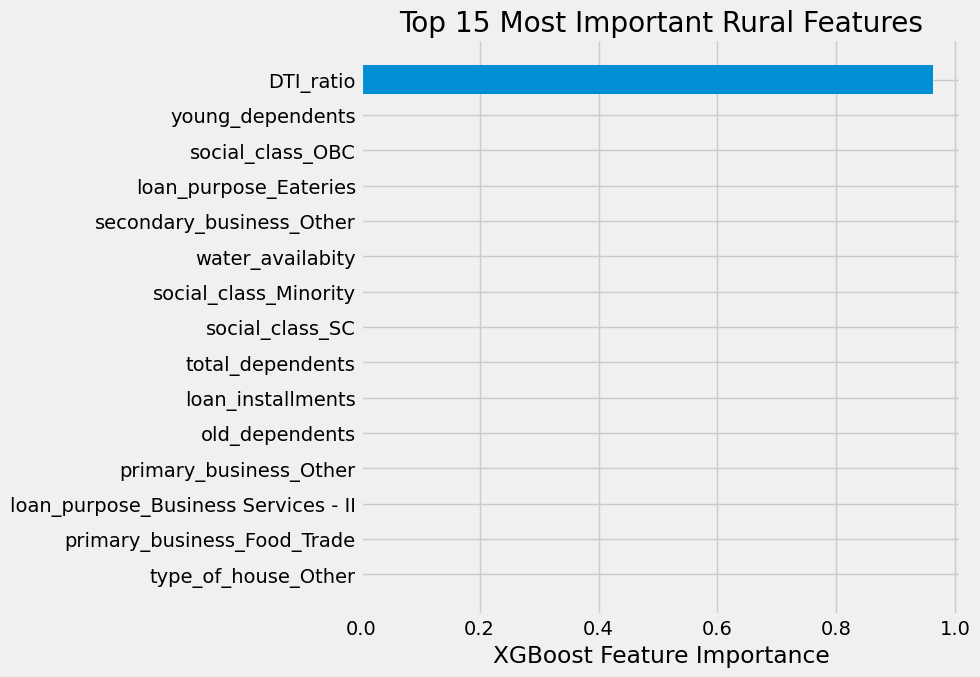

In [4]:
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': base_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

TOP_K = 15
top_features = importance_df.head(TOP_K)['Feature'].tolist()

print(f"--- Top {TOP_K} Features for Production ---")
for i, f in enumerate(top_features, 1):
    print(f"{i:>2}. {f}")

plt.figure(figsize=(10, 7))
plt.barh(
    importance_df['Feature'].head(TOP_K)[::-1],
    importance_df['Importance'].head(TOP_K)[::-1]
)
plt.xlabel("XGBoost Feature Importance")
plt.title(f"Top {TOP_K} Most Important Rural Features")
plt.tight_layout()
plt.show()

### Step 4: Retrain Production Model on Top 15 Features

In [5]:
X_train_top = X_train[top_features]
X_test_top  = X_test[top_features]

print(f"Retraining production model on top {TOP_K} features...")

final_model = xgb.XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=scale_pos_weight,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42,
    n_jobs=-1
)

final_model.fit(X_train_top, y_train)

final_preds  = final_model.predict_proba(X_test_top)[:, 1]
final_auc    = roc_auc_score(y_test, final_preds)
final_pr_auc = average_precision_score(y_test, final_preds)

print(f"\nFinal Production Model ROC-AUC : {final_auc:.4f}")
print(f"Final Production Model PR-AUC  : {final_pr_auc:.4f}")

Retraining production model on top 15 features...

Final Production Model ROC-AUC : 0.9936
Final Production Model PR-AUC  : 0.9492


### Step 5: Save Model & Feature Metadata to Backend

In [6]:
model_dir = '../../backend/ml_models/rural_microfinance'
os.makedirs(model_dir, exist_ok=True)

model_path    = os.path.join(model_dir, 'rural_xgb_model.joblib')
features_path = os.path.join(model_dir, 'rural_model_features.json')

# Save model
joblib.dump(final_model, model_path)
print(f"Saved model -> {model_path}")

# Save feature metadata
feature_metadata = {
    "module": "rural_microfinance",
    "model_type": "xgboost",
    "features": top_features,
    "feature_count": len(top_features),
    "metrics": {
        "roc_auc":  round(final_auc, 4),
        "pr_auc":   round(final_pr_auc, 4)
    }
}
with open(features_path, 'w') as f:
    json.dump(feature_metadata, f, indent=4)
print(f"Saved feature metadata -> {features_path}")
print("\nDone! Rural model is ready for the FastAPI backend.")

Saved model -> ../../backend/ml_models/rural_microfinance\rural_xgb_model.joblib
Saved feature metadata -> ../../backend/ml_models/rural_microfinance\rural_model_features.json

Done! Rural model is ready for the FastAPI backend.
